# 📊 Finance AI — Assistente Inteligente de Saúde Financeira

Caderno de Ciência de Dados do Projeto 2 (Hackathon ONE G9).

Este caderno parte do **raw data real** (`transacoes_sujas.csv`, construído pelo próprio time) e segue a sequência pedida no edital:

1. Exploração e limpeza dos dados (EDA)
2. Tratamento de variáveis financeiras e textuais
3. Engenharia de atributos
4. Classificação de despesas (modelo 1)
5. Agregação por usuário e análise de perfil financeiro
6. Classificação de perfil financeiro (modelo 2)
7. Geração de recomendações
8. Métricas de desempenho e serialização dos modelos
9. Exportação no formato de saída esperado pela API



## 1. Configuração do ambiente

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import joblib

plt.style.use('seaborn-v0_8-whitegrid') if 'seaborn-v0_8-whitegrid' in plt.style.available else plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10, 5)

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

print('✅ Bibliotecas carregadas com sucesso!')

✅ Bibliotecas carregadas com sucesso!


## 2. Carregamento dos dados

Carrega o `transacoes_sujas.csv` real do repositório do time (dataset sintético "sujo", com erros propositais de formatação — permitido pelo edital, que aceita dados gerados por simulação).

In [ ]:
URL_RAW_DATA = 'https://raw.githubusercontent.com/No-Country-simulation/G9-BR-Team23/refs/heads/main/data-science/raw/transacoes_sujas.csv'

df = pd.read_csv(URL_RAW_DATA, sep=';')
print(f'✅ Dados carregados: {df.shape[0]} transações, {df["user_id"].nunique()} usuários únicos.')
df.head()

✅ Dados carregados: 1050 transações, 50 usuários únicos.


,row_ref,user_id,file_id,transaction_date,amount,type,status,description,installments_remaining
0,TX0001,23,3.00,2023-03-13,2568.04,TED,FAILED,Supermercado,0
1,TX0002,49,3.00,2023-04-13,NaN,TED,PENDING,Farmácia,0
2,TX0003,38,NaN,2023-12-05,1856.35,BOLETO,COMPLETED,Restaurante,0
3,TX0004,16,1.00,2023-04-08,3138.07,DEBIT,PENDING,Farmácia,0
4,TX0005,31,2.00,2023-05-07,993.61,DEBIT,PENDING,Aluguel,0


## 3. Exploração inicial (EDA)

Antes de limpar, mapeamos exatamente quais problemas existem — para não "limpar no escuro".

In [ ]:
print('--- Estrutura ---')
print(df.info())

print('\n--- Valores nulos por coluna ---')
print(df.isnull().sum())

print('\n--- status (valores brutos) ---')
print(df['status'].value_counts(dropna=False))

print('\n--- amount (amostra bruta) ---')
print(df['amount'].dropna().sample(10, random_state=1).tolist())

print('\n--- transaction_date (amostra bruta) ---')
print(df['transaction_date'].dropna().sample(10, random_state=1).tolist())

print('\n--- description (valores únicos brutos) ---')
print(df['description'].value_counts(dropna=False))

--- Estrutura ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   row_ref                 1050 non-null   object 
 1   user_id                 1050 non-null   int64  
 2   file_id                 745 non-null    float64
 3   transaction_date        996 non-null    object 
 4   amount                  993 non-null    object 
 5   type                    1050 non-null   object 
 6   status                  1030 non-null   object 
 7   description             1050 non-null   object 
 8   installments_remaining  1050 non-null   int64  
dtypes: float64(1), int64(2), object(6)
memory usage: 74.0+ KB
None

--- Valores nulos por coluna ---
row_ref                     0
user_id                     0
file_id                   305
transaction_date           54
amount                     57
type                        0
status     

**Problemas identificados:**
- `amount`: decimal misto (`.` e `,`), ~5% de nulos
- `status`: variantes inconsistentes (`COMPLETEDD`, `PENDENTE`) além de nulos
- `transaction_date`: formatos mistos (`YYYY-MM-DD`, `DD/MM/YYYY`, `DD-MM-YYYY`) além de nulos
- `description`: espaços extras ao redor de alguns valores (ex.: `" Netflix"` vs `"Netflix"`)
- `file_id`: ~27% de nulos — não é usado nas etapas seguintes (é só identificador de lote de extração)

## 4. Limpeza dos dados

In [ ]:
df_clean = df.copy()

# description: remover espaços extras
df_clean['description'] = df_clean['description'].str.strip()

# status: normalizar grafias inconsistentes e nulos
status_map = {'COMPLETEDD': 'COMPLETED', 'PENDENTE': 'PENDING'}
df_clean['status'] = df_clean['status'].str.strip().replace(status_map)
df_clean['status'] = df_clean['status'].fillna('NAO_INFORMADO')

# amount: vírgula -> ponto, cast para float; remove linhas sem valor (não é possível
# classificar/agregar uma transação sem saber o valor)
df_clean['amount'] = df_clean['amount'].astype(str).str.replace(',', '.', regex=False)
df_clean['amount'] = pd.to_numeric(df_clean['amount'], errors='coerce')
n_antes = len(df_clean)
df_clean = df_clean.dropna(subset=['amount']).copy()
print(f'Linhas removidas por falta de amount: {n_antes - len(df_clean)} ({(n_antes - len(df_clean))/n_antes:.1%})')

# transaction_date: parser tolerante a múltiplos formatos
def parse_data(valor):
    if pd.isna(valor):
        return pd.NaT
    valor = str(valor).strip()
    for fmt in ('%Y-%m-%d', '%d/%m/%Y', '%d-%m-%Y'):
        try:
            return pd.to_datetime(valor, format=fmt)
        except ValueError:
            continue
    return pd.NaT

df_clean['transaction_date'] = df_clean['transaction_date'].apply(parse_data)
print(f'Datas ausentes/irreconhecíveis: {df_clean["transaction_date"].isna().sum()} (mantidas como NaT — não impedem a análise por usuário)')

# checagem de duplicatas
print(f'Transações duplicadas (row_ref): {df_clean["row_ref"].duplicated().sum()}')
print(f'Linhas 100% duplicadas: {df_clean.duplicated().sum()}')

df_clean.head()

Linhas removidas por falta de amount: 57 (5.4%)
Datas ausentes/irreconhecíveis: 53 (mantidas como NaT — não impedem a análise por usuário)
Transações duplicadas (row_ref): 0
Linhas 100% duplicadas: 0


,row_ref,user_id,file_id,transaction_date,amount,type,status,description,installments_remaining
0,TX0001,23,3.00,2023-03-13,"2,568.04",TED,FAILED,Supermercado,0
2,TX0003,38,NaN,2023-12-05,"1,856.35",BOLETO,COMPLETED,Restaurante,0
3,TX0004,16,1.00,2023-04-08,"3,138.07",DEBIT,PENDING,Farmácia,0
4,TX0005,31,2.00,2023-05-07,993.61,DEBIT,PENDING,Aluguel,0
5,TX0006,32,3.00,2023-09-01,"3,712.66",TED,NAO_INFORMADO,Uber,0


## 5. Engenharia de atributos — categorização das despesas

Mapeamos cada `description` para uma categoria financeira do enunciado. Esse mapeamento é o **rótulo de treino** do primeiro modelo (a ideia é que, com uma base maior e descrições mais livres/ruidosas no futuro, o modelo generalize além deste dicionário fixo).

In [ ]:
mapa_categoria = {
    'Supermercado': 'Alimentacao',
    'Restaurante': 'Alimentacao',
    'Uber': 'Transporte',
    'Posto Gasolina': 'Transporte',
    'Farmácia': 'Saude',
    'Aluguel': 'Moradia',
    'Netflix': 'Lazer',
    'Amazon': 'Servicos',
    # 'Educação' não tem exemplos nesta base — pode ser adicionada quando houver
    # descrições do tipo 'Mensalidade Escolar', 'Curso', etc.
}

df_clean['categoria'] = df_clean['description'].map(mapa_categoria)
print(df_clean['categoria'].value_counts(dropna=False))

categoria
Transporte     246
Alimentacao    239
Lazer          157
Saude          129
Moradia        121
Servicos       101
Name: count, dtype: int64


## 6. Modelo 1 — Classificação automática de despesas

Classificador supervisionado (TF-IDF + Regressão Logística) que aprende a mapear a descrição da transação para a categoria financeira.

In [ ]:
X = df_clean['description']
y = df_clean['categoria']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

modelo_categoria = Pipeline([
    ('tfidf', TfidfVectorizer(lowercase=True, ngram_range=(1, 2))),
    ('clf', LogisticRegression(max_iter=1000)),
])
modelo_categoria.fit(X_train, y_train)

y_pred = modelo_categoria.predict(X_test)
print(f'Acurácia: {accuracy_score(y_test, y_pred):.3f}')
print(f'F1 macro: {f1_score(y_test, y_pred, average="macro"):.3f}')
print(classification_report(y_test, y_pred))

Acurácia: 1.000
F1 macro: 1.000
              precision    recall  f1-score   support

 Alimentacao       1.00      1.00      1.00        48
       Lazer       1.00      1.00      1.00        32
     Moradia       1.00      1.00      1.00        24
       Saude       1.00      1.00      1.00        26
    Servicos       1.00      1.00      1.00        20
  Transporte       1.00      1.00      1.00        49

    accuracy                           1.00       199
   macro avg       1.00      1.00      1.00       199
weighted avg       1.00      1.00      1.00       199



**Nota:** a acurácia fica em ~100% porque o vocabulário de comerciantes desta base é fechado e determinístico (8 descrições distintas mapeadas 1:1 para categoria). Isso é esperado nesta fase — o pipeline (TF-IDF + classificador supervisionado, com treino/teste e métricas) é o mesmo que seria usado com descrições livres e mais ruidosas de um extrato bancário real, onde a acurácia tende a cair e passa a justificar de fato um modelo (em vez de um dicionário simples).

In [ ]:
joblib.dump(modelo_categoria, 'modelo_categoria_despesa.pkl')
print('✅ Modelo de categoria serializado em modelo_categoria_despesa.pkl')

df_clean['categoria_predita'] = modelo_categoria.predict(df_clean['description'])

✅ Modelo de categoria serializado em modelo_categoria_despesa.pkl


## 7. Agregação por usuário

As variáveis financeiras usadas na análise de perfil são **derivadas das transações reais** (gasto total, gasto por categoria, parcelas em aberto, taxa de falha) sempre que possível.

Os únicos campos que o CSV de transações não permite observar diretamente — renda mensal declarada e limite de cartão — são simulados com **seed fixa** e **ancorados no gasto real** de cada usuário (ex.: renda como múltiplo do gasto mensal observado)

Renda mensal = gasto mensal real do usuário × um número aleatório entre 0,85 e 3,0 (mínimo R$ 1.500).
Limite do cartão = renda mensal simulada × um número aleatório entre 0,8 e 2,0.

In [ ]:
N_MESES_OBSERVADOS = 12  # a base cobre transações ao longo de 2023

agg_base = df_clean.groupby('user_id').agg(
    gasto_total=('amount', 'sum'),
    n_transacoes=('amount', 'count'),
    ticket_medio=('amount', 'mean'),
    n_failed=('status', lambda s: (s == 'FAILED').sum()),
).reset_index()
agg_base['pct_failed'] = agg_base['n_failed'] / agg_base['n_transacoes']

pivot_categoria = df_clean.pivot_table(
    index='user_id', columns='categoria', values='amount', aggfunc='sum', fill_value=0
).reset_index()

parcelas = (
    df_clean[df_clean['installments_remaining'] > 0]
    .groupby('user_id')['amount'].max()
    .rename('parcela_mais_cara')
    .reset_index()
)

agg = (
    agg_base
    .merge(pivot_categoria, on='user_id', how='left')
    .merge(parcelas, on='user_id', how='left')
)
agg['parcela_mais_cara'] = agg['parcela_mais_cara'].fillna(0)

categorias_gasto = ['Alimentacao', 'Transporte', 'Saude', 'Moradia', 'Lazer', 'Servicos']
for cat in categorias_gasto:
    if cat not in agg.columns:
        agg[cat] = 0.0

# despesas fixas reais: Moradia + Lazer recorrente (assinaturas) + Saúde, por mês
agg['despesas_fixas'] = (agg['Moradia'] + agg['Lazer'] + agg['Saude']) / N_MESES_OBSERVADOS

# proxy real de dívida: BOLETO + CREDIT, por mês
gastos_divida = (
    df_clean[df_clean['type'].isin(['BOLETO', 'CREDIT'])]
    .groupby('user_id')['amount'].sum() / N_MESES_OBSERVADOS
)
agg = agg.merge(gastos_divida.rename('gastos_dividas').reset_index(), on='user_id', how='left')
agg['gastos_dividas'] = agg['gastos_dividas'].fillna(0)

# proxy real de fatura de cartão: CREDIT, por mês
fatura = df_clean[df_clean['type'] == 'CREDIT'].groupby('user_id')['amount'].sum() / N_MESES_OBSERVADOS
agg = agg.merge(fatura.rename('fatura_cartao').reset_index(), on='user_id', how='left')
agg['fatura_cartao'] = agg['fatura_cartao'].fillna(0)

agg.head()

,user_id,gasto_total,n_transacoes,ticket_medio,n_failed,pct_failed,Alimentacao,Lazer,Moradia,Saude,Servicos,Transporte,parcela_mais_cara,despesas_fixas,gastos_dividas,fatura_cartao
0,1,"74,664.77",26,"2,871.72",7,0.27,"20,953.34","24,334.43",893.73,"16,661.72","4,087.25","7,734.30","4,392.53","3,490.82","3,618.48","1,971.42"
1,2,"44,425.49",15,"2,961.70",3,0.20,"23,684.53","3,300.50","4,899.47","4,459.19","4,994.22","3,087.58","2,244.91","1,054.93","1,382.42",319.58
2,3,"44,326.07",17,"2,607.42",5,0.29,"10,670.08","7,462.09","6,170.59","3,053.69","1,800.41","15,169.21","3,878.60","1,390.53","3,118.82",784.11
3,4,"31,220.43",11,"2,838.22",2,0.18,"10,716.55",0.00,"9,938.07","5,586.62",215.12,"4,764.07","4,900.52","1,293.72","1,660.48",795.51
4,5,"58,517.89",23,"2,544.26",9,0.39,"10,120.47","13,454.23","3,865.81","12,736.29","7,291.25","11,049.84","4,423.01","2,504.69","3,052.61","1,726.63"


In [ ]:
# Campos simulados (fixos por seed, ancorados no gasto real observado) —
# a base de transações não contém renda declarada nem limite de cartão.
rng = np.random.default_rng(42)
agg = agg.sort_values('user_id').reset_index(drop=True)

agg['gasto_mensal_total'] = agg['gasto_total'] / N_MESES_OBSERVADOS
fator_renda = rng.uniform(0.85, 3.0, size=len(agg))
agg['renda_mensal'] = (agg['gasto_mensal_total'] * fator_renda).clip(lower=1500)
agg['limite_cartao'] = agg['renda_mensal'] * rng.uniform(0.8, 2.0, size=len(agg))
agg['reserva_atual'] = agg['despesas_fixas'] * rng.uniform(0.2, 4.0, size=len(agg))
agg['poupado_mes'] = (
    (agg['renda_mensal'] - agg['gasto_mensal_total']).clip(lower=0)
    * rng.uniform(0.3, 0.9, size=len(agg))
)

agg[['user_id', 'renda_mensal', 'despesas_fixas', 'gastos_dividas', 'fatura_cartao',
     'limite_cartao', 'reserva_atual', 'poupado_mes']].head()

,user_id,renda_mensal,despesas_fixas,gastos_dividas,fatura_cartao,limite_cartao,reserva_atual,poupado_mes
0,1,"15,642.30","3,490.82","3,618.48","1,971.42","16,266.27","12,750.60","7,496.39"
1,2,"6,640.09","1,054.93","1,382.42",319.58,"5,370.73","3,015.93","2,461.12"
2,3,"9,958.54","1,390.53","3,118.82",784.11,"17,370.77","1,682.97","2,406.58"
3,4,"6,112.29","1,293.72","1,660.48",795.51,"9,766.34","5,023.36","2,220.17"
4,5,"5,132.42","2,504.69","3,052.61","1,726.63","8,448.97","7,912.96",93.45


## 8. Regras de mercado → indicadores e rótulo de perfil

Reaproveitamos as 5 regras de ouro (Febraban, BCB, Planejar, Serasa) e elas leem as variáveis calculadas acima (reais + simuladas de forma ancorada).

Elas geram um **score contínuo** e, a partir dele, o rótulo de perfil (`Saudável` / `Em observação` / `Em risco`) que serve de alvo para o modelo supervisionado do próximo passo.

In [ ]:
def calcular_indicadores(row):
    cobertura_meses = row['reserva_atual'] / row['despesas_fixas'] if row['despesas_fixas'] > 0 else 0
    comprometimento_pct = (row['gastos_dividas'] / row['renda_mensal']) * 100 if row['renda_mensal'] > 0 else 0
    taxa_poupanca_pct = (row['poupado_mes'] / row['renda_mensal']) * 100 if row['renda_mensal'] > 0 else 0
    utilizacao_cartao_pct = (row['fatura_cartao'] / row['limite_cartao']) * 100 if row['limite_cartao'] > 0 else 0
    return pd.Series({
        'cobertura_meses': cobertura_meses,
        'comprometimento_pct': comprometimento_pct,
        'taxa_poupanca_pct': taxa_poupanca_pct,
        'utilizacao_cartao_pct': utilizacao_cartao_pct,
    })

agg = agg.join(agg.apply(calcular_indicadores, axis=1))

def score_regra(row):
    # cada indicador contribui até 25 pontos, conforme a diretriz de mercado associada
    s_reserva = min(row['cobertura_meses'] / 3, 1) * 25          # BCB: 3 meses
    s_comprometimento = max(1 - row['comprometimento_pct'] / 30, 0) * 25  # Febraban: teto 30%
    s_poupanca = min(row['taxa_poupanca_pct'] / 10, 1) * 25       # Planejar: mínimo 10%
    s_cartao = max(1 - row['utilizacao_cartao_pct'] / 50, 0) * 25 # Serasa: teto 50%
    return s_reserva + s_comprometimento + s_poupanca + s_cartao

agg['score_isfb'] = agg.apply(score_regra, axis=1).round(1)

def faixa_perfil(score):
    if score >= 70:
        return 'Saudavel'
    elif score >= 40:
        return 'Em observacao'
    else:
        return 'Em risco'

agg['perfil_financeiro'] = agg['score_isfb'].apply(faixa_perfil)
print(agg['perfil_financeiro'].value_counts())

perfil_financeiro
Em observacao    24
Saudavel         23
Em risco          3
Name: count, dtype: int64


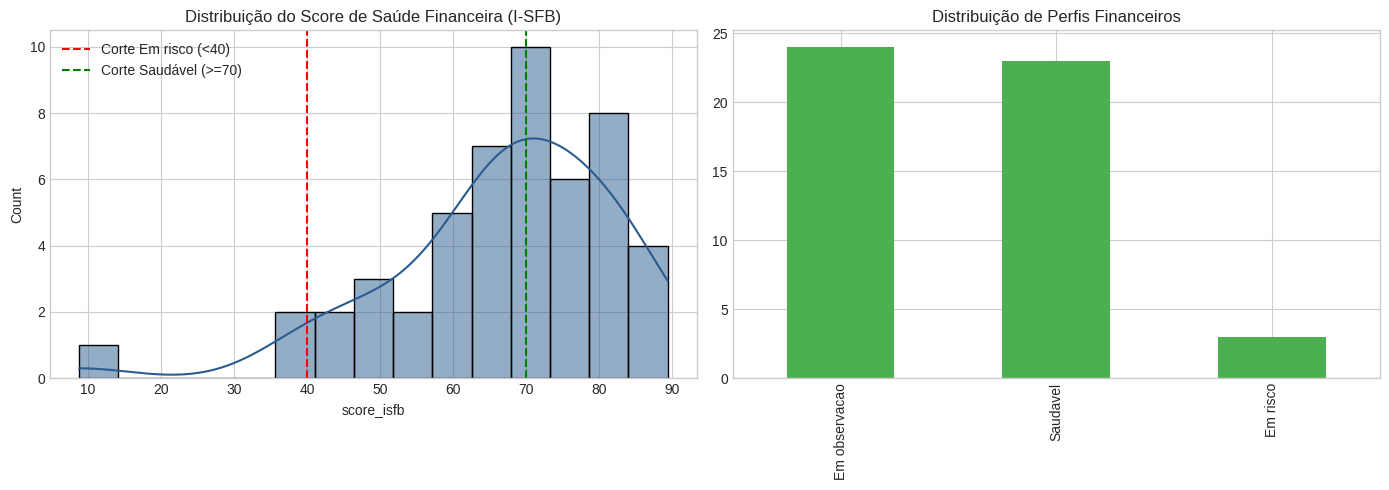

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(agg['score_isfb'], kde=True, ax=axes[0], color='#2b5c8f', bins=15)
axes[0].axvline(40, color='red', linestyle='--', label='Corte Em risco (<40)')
axes[0].axvline(70, color='green', linestyle='--', label='Corte Saudável (>=70)')
axes[0].set_title('Distribuição do Score de Saúde Financeira (I-SFB)')
axes[0].legend()

agg['perfil_financeiro'].value_counts().plot(kind='bar', ax=axes[1], color='#4caf50')
axes[1].set_title('Distribuição de Perfis Financeiros')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

## 9. Modelo 2 — Classificação de perfil financeiro

Treinamos um classificador supervisionado (Random Forest) para prever o perfil financeiro a partir dos indicadores agregados — usando o rótulo gerado pelas regras de mercado como alvo de treino. Isso permite que, em produção, a API classifique um novo usuário sem precisar recalcular manualmente as 5 regras a cada chamada, além de expor uma probabilidade de confiança (como pedido no formato de saída do edital).

**Limitação a documentar:** a base tem só 50 usuários, então o conjunto de teste é pequeno (10 usuários) e a classe "Em risco" tem poucos exemplos — as métricas abaixo devem ser lidas com essa ressalva. Ampliar a base sintética (mais usuários) é a melhoria mais direta para tornar essa avaliação mais robusta.

In [ ]:
features = ['renda_mensal', 'despesas_fixas', 'gastos_dividas', 'fatura_cartao',
            'limite_cartao', 'reserva_atual', 'poupado_mes', 'cobertura_meses',
            'comprometimento_pct', 'taxa_poupanca_pct', 'utilizacao_cartao_pct']

X2 = agg[features]
y2 = agg['perfil_financeiro']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

modelo_perfil = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=42)),
])
modelo_perfil.fit(X2_train, y2_train)

y2_pred = modelo_perfil.predict(X2_test)
print(f'Acurácia: {accuracy_score(y2_test, y2_pred):.3f}')
print(f'F1 macro: {f1_score(y2_test, y2_pred, average="macro"):.3f}')
print(classification_report(y2_test, y2_pred, zero_division=0))

Acurácia: 0.900
F1 macro: 0.636
               precision    recall  f1-score   support

Em observacao       0.83      1.00      0.91         5
     Em risco       0.00      0.00      0.00         1
     Saudavel       1.00      1.00      1.00         4

     accuracy                           0.90        10
    macro avg       0.61      0.67      0.64        10
 weighted avg       0.82      0.90      0.85        10



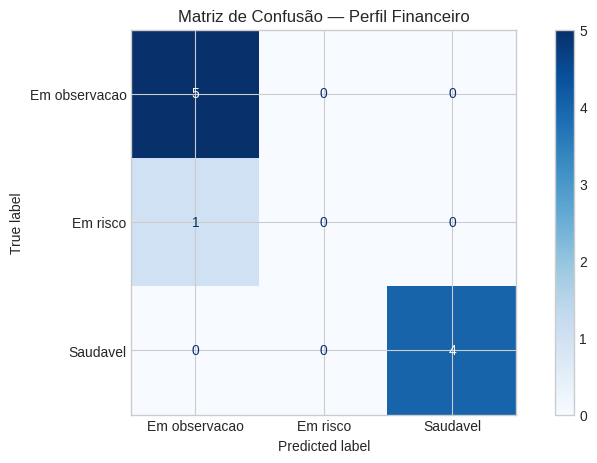

In [ ]:
cm = confusion_matrix(y2_test, y2_pred, labels=modelo_perfil.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo_perfil.classes_)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão — Perfil Financeiro')
plt.show()

In [ ]:
joblib.dump(modelo_perfil, 'modelo_perfil_financeiro.pkl')
print('✅ Modelo de perfil financeiro serializado em modelo_perfil_financeiro.pkl')

agg['perfil_predito_modelo'] = modelo_perfil.predict(X2)
agg['probabilidade_modelo'] = modelo_perfil.predict_proba(X2).max(axis=1).round(2)

✅ Modelo de perfil financeiro serializado em modelo_perfil_financeiro.pkl


## 10. Motor de recomendações

Utiliza as 5 regras lendo os indicadores calculados sobre dados reais/ancorados.

In [ ]:
def rec_reserva(row):
    if row['cobertura_meses'] < 3:
        return f"Sua reserva cobre {row['cobertura_meses']:.1f} meses de despesas fixas; a meta do BCB é 3 a 6 meses."
    return None

def rec_comprometimento(row):
    if row['comprometimento_pct'] > 30:
        return f"Comprometimento de renda em {row['comprometimento_pct']:.1f}%, acima do teto de 30% recomendado pela Febraban."
    return None

def rec_poupanca(row):
    if row['taxa_poupanca_pct'] < 10:
        return f"Taxa de poupança de {row['taxa_poupanca_pct']:.1f}%, abaixo da meta de 10% da Planejar."
    return None

def rec_cartao(row):
    if row['utilizacao_cartao_pct'] > 50:
        return f"Uso de {row['utilizacao_cartao_pct']:.1f}% do limite do cartão, acima do teto seguro de 50%."
    return None

def gerar_recomendacoes(row):
    return [r for r in [rec_reserva(row), rec_comprometimento(row), rec_poupanca(row), rec_cartao(row)] if r]

agg['recomendacoes'] = agg.apply(gerar_recomendacoes, axis=1)
agg[['user_id', 'perfil_predito_modelo', 'recomendacoes']].head()

,user_id,perfil_predito_modelo,recomendacoes
0,1,Saudavel,[]
1,2,Saudavel,[Sua reserva cobre 2.9 meses de despesas fixas...
2,3,Em observacao,[Sua reserva cobre 1.2 meses de despesas fixas...
3,4,Saudavel,[]
4,5,Em observacao,"[Comprometimento de renda em 59.5%, acima do t..."


## 11. Saída no formato esperado pela API

Monta o JSON exatamente no formato do exemplo do edital (`perfil_financeiro`, `probabilidade`, `resumo_gastos`, `recomendacoes`) — este é o payload que o endpoint `POST /analise-financeira` do back-end deve devolver.

In [ ]:
def montar_json_usuario(user_id):
    row = agg[agg['user_id'] == user_id].iloc[0]
    resumo_gastos = {cat.lower(): round(float(row[cat]), 2) for cat in categorias_gasto}
    return {
        'user_id': int(user_id),
        'perfil_financeiro': row['perfil_predito_modelo'],
        'probabilidade': float(row['probabilidade_modelo']),
        'resumo_gastos': resumo_gastos,
        'recomendacoes': row['recomendacoes'],
    }

# 3 exemplos reais de utilização (requisito mínimo do edital)
exemplos = [int(uid) for uid in agg['user_id'].head(3)]
for uid in exemplos:
    print(json.dumps(montar_json_usuario(uid), indent=2, ensure_ascii=False))
    print()

{
  "user_id": 1,
  "perfil_financeiro": "Saudavel",
  "probabilidade": 0.76,
  "resumo_gastos": {
    "alimentacao": 20953.34,
    "transporte": 7734.3,
    "saude": 16661.72,
    "moradia": 893.73,
    "lazer": 24334.43,
    "servicos": 4087.25
  },
  "recomendacoes": []
}

{
  "user_id": 2,
  "perfil_financeiro": "Saudavel",
  "probabilidade": 0.87,
  "resumo_gastos": {
    "alimentacao": 23684.53,
    "transporte": 3087.58,
    "saude": 4459.19,
    "moradia": 4899.47,
    "lazer": 3300.5,
    "servicos": 4994.22
  },
  "recomendacoes": [
    "Sua reserva cobre 2.9 meses de despesas fixas; a meta do BCB é 3 a 6 meses."
  ]
}

{
  "user_id": 3,
  "perfil_financeiro": "Em observacao",
  "probabilidade": 0.94,
  "resumo_gastos": {
    "alimentacao": 10670.08,
    "transporte": 15169.21,
    "saude": 3053.69,
    "moradia": 6170.59,
    "lazer": 7462.09,
    "servicos": 1800.41
  },
  "recomendacoes": [
    "Sua reserva cobre 1.2 meses de despesas fixas; a meta do BCB é 3 a 6 meses.",


## 12. Exportação dos resultados

In [ ]:
agg.to_csv('relatorio_saude_financeira.csv', index=False, encoding='utf-8-sig')
print('✅ relatorio_saude_financeira.csv exportado')
print('✅ modelo_categoria_despesa.pkl e modelo_perfil_financeiro.pkl prontos para o back-end carregar')

✅ relatorio_saude_financeira.csv exportado
✅ modelo_categoria_despesa.pkl e modelo_perfil_financeiro.pkl prontos para o back-end carregar


## 13. Pendências para a entrega completa (fora deste caderno)

Este caderno cobre a parte de **Ciência de Dados** do edital. Ainda faltam, para o MVP completo:

- **Back-end (API REST):** carregar `modelo_categoria_despesa.pkl` e `modelo_perfil_financeiro.pkl`, expor os endpoints `/analise-financeira` e de classificação de transações, validar entrada e tratar erros.
- **OCI:** subir pelo menos os `.pkl` (e opcionalmente o CSV) para um bucket de Object Storage — é o caminho mais rápido para cumprir o requisito de integração com OCI.
- **Documentação da arquitetura** de ponta a ponta (Colab → modelos serializados → API → OCI).
- Ampliar a base sintética (mais usuários e mais descrições de transação) para tornar as métricas do modelo de perfil mais robustas — hoje o teste tem só 10 usuários.